In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

In [ ]:
# Загрузка и первичная обработка данных ---
df = pd.read_csv("/content/dataset_for_SI.csv")
df.head(10)

,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,...,0,0,0,0,0,0,0,0,3,0
1,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,...,0,0,0,0,0,0,0,0,3,0
2,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,...,0,0,0,0,0,0,0,0,3,0
3,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,...,0,0,0,0,0,0,0,0,0,0
4,2.000000,5.758408,5.758408,0.278083,0.278083,0.711012,28.600000,332.491,304.267,332.225249,...,0,0,0,0,0,0,0,0,0,0
5,0.770000,2.584472,2.584472,0.429649,0.429649,0.328539,36.564103,528.869,472.421,528.443253,...,0,0,0,0,0,0,0,0,0,0
6,0.820000,13.821880,13.821880,0.079845,-0.301260,0.217332,31.333333,695.089,624.529,694.543729,...,0,0,0,0,0,0,0,0,4,0
7,3.070681,14.171614,14.171614,0.019123,-0.411828,0.187781,29.157895,763.123,696.595,762.512429,...,0,0,0,0,0,0,0,0,0,0
8,7.857143,5.856558,5.856558,0.246833,0.246833,0.701837,28.440000,334.463,308.255,334.204513,...,0,0,0,0,0,0,0,0,0,0
9,1.664336,2.589342,2.589342,0.380221,0.380221,0.640283,33.250000,328.564,290.260,328.299877,...,0,0,0,0,0,0,0,0,0,0


Посмотрим на распределение целевой переменной

<Axes: xlabel='SI', ylabel='Count'>

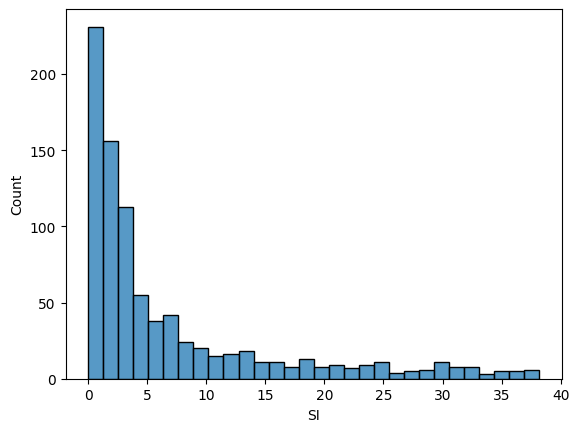

In [ ]:
sns.histplot(df['SI'], bins=30)

Видим, что большинство значений расположено в диапазоне от 0 до 10 и присутствует длинный правый хвост.

In [ ]:
# Разделение на признаки и целевую переменную
X = df.drop('SI', axis=1)
THRESHOLD = 8

df['SI_byn'] = (df['SI'] > THRESHOLD).astype(int)

y = df['SI_byn']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Посмотрим на балансировку данных по классам

<Axes: xlabel='SI_byn', ylabel='Count'>

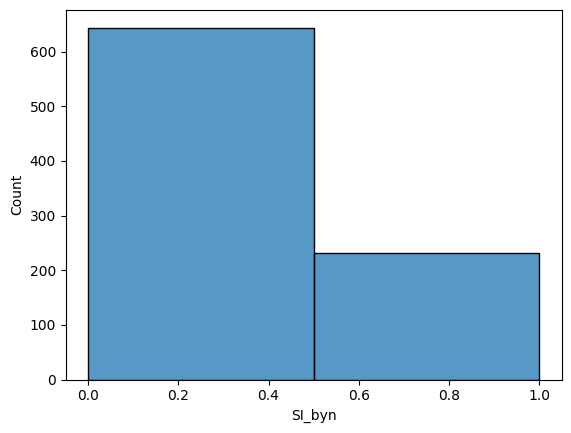

In [ ]:
sns.histplot(y, bins=2)

Видим серьъезный дисбаланс. Устраним его с помощью RandomOverSampler

In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

<Axes: xlabel='SI_byn', ylabel='Count'>

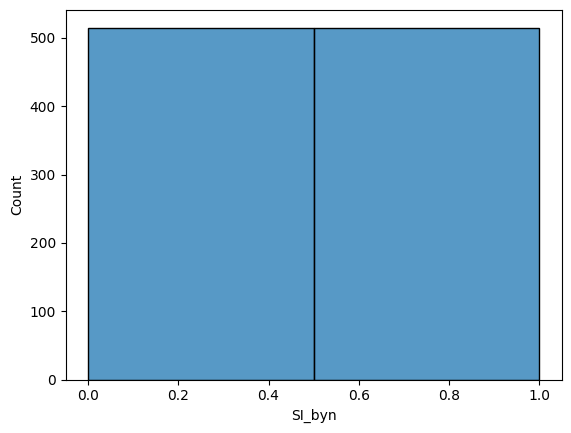

In [ ]:
sns.histplot(y_resampled, bins=2)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        # Обучение с кросс-валидацией
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        acc_cv = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv).mean()
        prec_cv = cross_val_score(model, X_train, y_train, scoring='precision', cv=cv).mean()
        rec_cv = cross_val_score(model, X_train, y_train, scoring='recall', cv=cv).mean()
        f1_cv = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv).mean()


        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc_test = accuracy_score(y_test, y_pred)
        prec_test = precision_score(y_test, y_pred)
        rec_test = recall_score(y_test, y_pred)
        f1_test = f1_score(y_test, y_pred)

        results.append({
            'Model': name,
            'CV Accuracy': acc_cv,
            'CV Precision': prec_cv,
            'CV Recall': rec_cv,
            'CV F1': f1_cv,
            'Test Accuracy': acc_test,
            'Test Precision': prec_test,
            'Test Recall': rec_test,
            'Test F1': f1_test
        })

        return results


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=200, class_weights=[1, 3], verbose=0)
}

In [ ]:
results = evaluate_models(models, X_train_scaled, y_resampled, X_test_scaled, y_test)
results_df = pd.DataFrame(results)
results_df.sort_values(by='Test F1', ascending=False, inplace=True)
print(results_df.round(4))

           Model  CV Accuracy  CV Precision  CV Recall   CV F1  Test Accuracy  \
0  Random Forest       0.8612        0.8287     0.9203  0.8703         0.6761   

   Test Precision  Test Recall  Test F1  
0          0.4038       0.4468   0.4242  


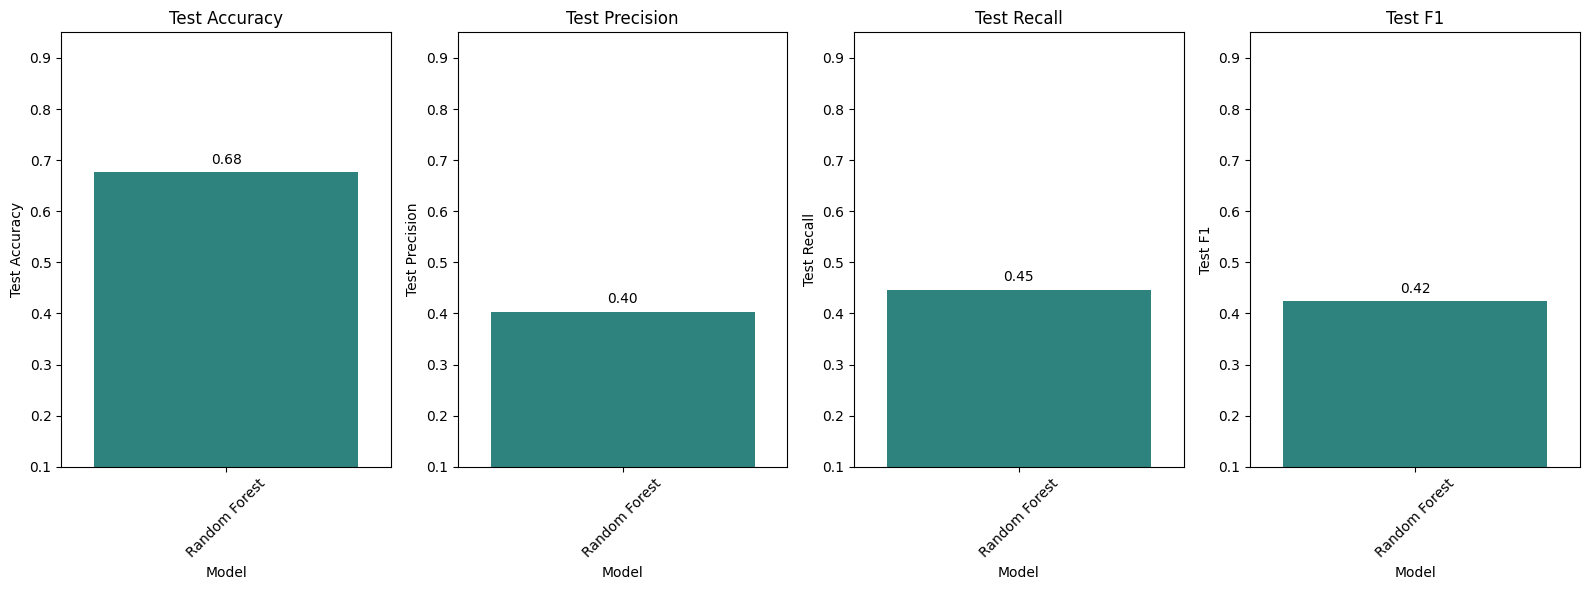

In [ ]:
# Метрики для визуализации
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

plt.figure(figsize=(16, 6))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(x='Model', y=f'Test {metric}', data=results_df, palette="viridis", hue='Model', legend=False)
    plt.title(f'Test {metric}')
    plt.ylim(0.1, 0.95)
    plt.xticks(rotation=45)

    # Добавление подписей значений
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# Параметры для подбора
params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 300, 400],
    'class_weights': [[1,1], [1, 2], [1, 3]]
}

# Инициализация модели
model = CatBoostClassifier(iterations=200, class_weights=[1, 3], verbose=0)

# GridSearchCV
grid_search = GridSearchCV(model, params, cv=10, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_resampled)

# Лучшая модель
best_model = grid_search.best_estimator_
print("Лучшие параметры:", grid_search.best_params_)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Лучшие параметры: {'class_weights': [1, 2], 'iterations': 400, 'learning_rate': 0.1}


Добавим результат к остальным

In [17]:
y_pred = best_model.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred)
prec_test = precision_score(y_test, y_pred)
rec_test = recall_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred)
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'CatBoost tuned',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.6590909090909091
Test Precision: 0.38596491228070173
Test Recall: 0.46808510638297873
Test F1: 0.4230769230769231


И визуализируем его

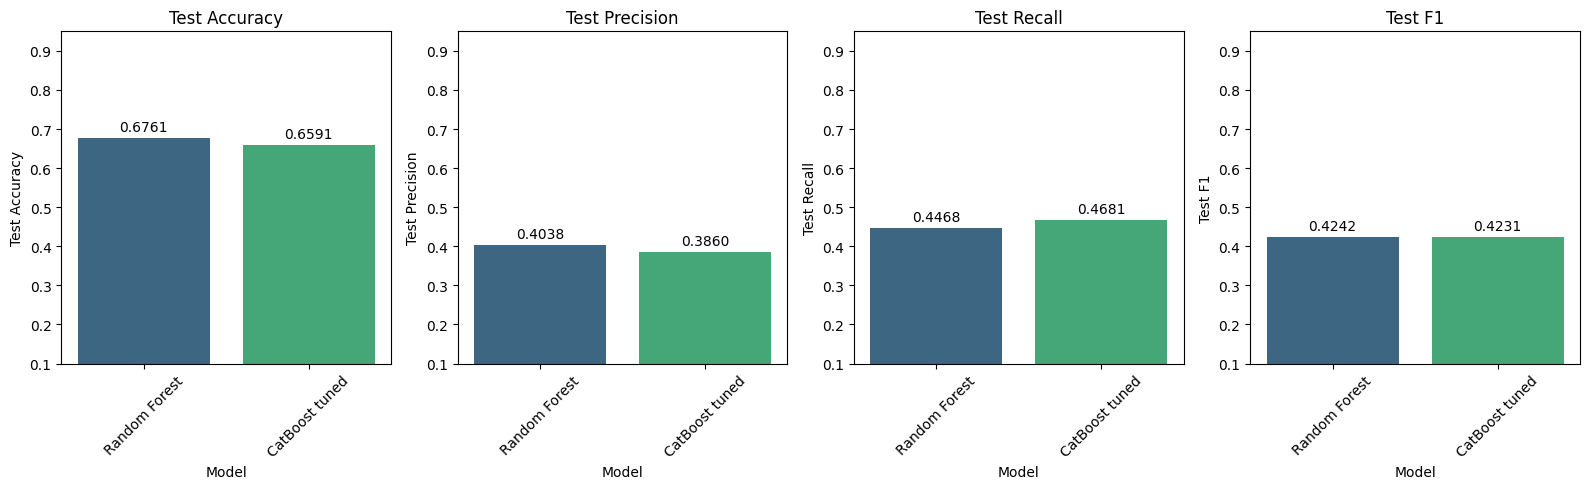

In [18]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(16, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(x='Model', y=f'Test {metric}', data=results_df, palette="viridis", hue='Model', legend=False)
    plt.title(f'Test {metric}')
    plt.ylim(0.1, 0.95)
    plt.xticks(rotation=45)

    # Добавление подписей значений
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Результат получился немного лучше предыдущего. Попробуем подобрать порог вероятности, максимизирующий F1


In [19]:
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
thresholds = np.linspace(0.1, 0.9, 100)
best_f1 = 0.0
best_threshold = 0.5

for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Лучший порог: {best_threshold:.2f}, F1: {best_f1:.4f}")

Лучший порог: 0.74, F1: 0.4651


In [21]:
y_pred_74 = (y_pred_proba >= best_threshold).astype(int)

acc_test = accuracy_score(y_test, y_pred_74)
prec_test = precision_score(y_test, y_pred_74)
rec_test = recall_score(y_test, y_pred_74)
f1_test = f1_score(y_test, y_pred_74)
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'CatBoost tresh=0.27',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.7386363636363636
Test Precision: 0.5128205128205128
Test Recall: 0.425531914893617
Test F1: 0.46511627906976744


In [22]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Выбираем порог, который максимизирует tpr - fpr (разделение классов)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Оптимальный порог по ROC:", optimal_threshold)

Оптимальный порог по ROC: 0.7459774181724773


In [23]:
y_pred_75 = (y_pred_proba >= best_threshold).astype(int)

acc_test = accuracy_score(y_test, y_pred_75)
prec_test = precision_score(y_test, y_pred_75)
rec_test = recall_score(y_test, y_pred_75)
f1_test = f1_score(y_test, y_pred_75)
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'CatBoost tresh=0.28',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.7386363636363636
Test Precision: 0.5128205128205128
Test Recall: 0.425531914893617
Test F1: 0.46511627906976744


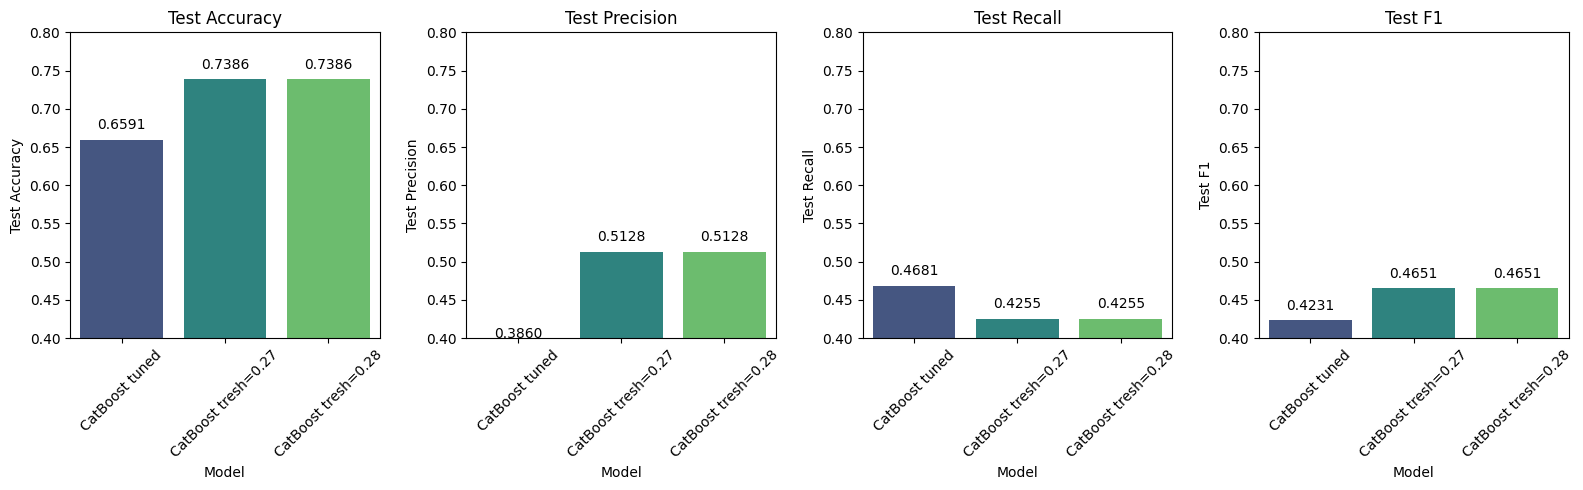

In [24]:
results_df = pd.DataFrame(results)
res_svm = results_df[results_df['Model'].isin(['CatBoost', 'CatBoost tuned', 'CatBoost tresh=0.27', 'CatBoost tresh=0.28'])]

plt.figure(figsize=(16, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(x='Model', y=f'Test {metric}', data=res_svm, palette="viridis", hue='Model', legend=False)
    plt.title(f'Test {metric}')
    plt.ylim(0.4, 0.8)
    plt.xticks(rotation=45)

    # Добавление подписей значений
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()